# **Telecommunication Customer Churn Data Analysis**

## Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
data = pd.read_csv('../Data/telcoData.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Overview

In [6]:
data.shape

(7043, 21)

In [7]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [8]:
data.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [9]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
data.describe(include='object')

C:\Users\Saqib\AppData\Local\Temp\ipykernel_40688\3382516499.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include='object')


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [11]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data overview:
- there are 21 calumns and 7043 rows
- total charges are in object format instead of float format.
- there are no null values

## Data Cleaning

In [12]:
# changing TotalCharges data type from object to float64

data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors = 'coerce')
data['TotalCharges'].dtype

dtype('float64')

In [18]:
data = data.drop('customerID', axis=1)

## EDA

In [19]:
cat_cols = data.select_dtypes(include = 'object').drop(columns = ['Churn'])
target_col = data['Churn']
num_cols = data.select_dtypes(exclude = 'object')

C:\Users\Saqib\AppData\Local\Temp\ipykernel_40688\3468342305.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include = 'object').drop(columns = ['Churn'])


### Target Variable Analysis

In [20]:
Churn_no = sum(data['Churn'] == 'No')
Churn_yes = sum(data['Churn'] == 'Yes')

non_churn_percentage = (Churn_no/len(data)) * 100
churn_percentage = (Churn_yes/len(data)) * 100

print(f'Churn_no : {non_churn_percentage:.2f}%')
print(f'Churn_yes : {churn_percentage:.2f}%')

Churn_no : 73.46%
Churn_yes : 26.54%


High Imbalance in the target column as only 26.5% customer churned. It means the Churn Rate is 26.5%

This class imbalance suggests that accuracy alone may be misleading and evaluation metrics such as ROC-AUC, Precision-Recall, and Recall for churned customers should be prioritized.

### Numarical Variable Analysis

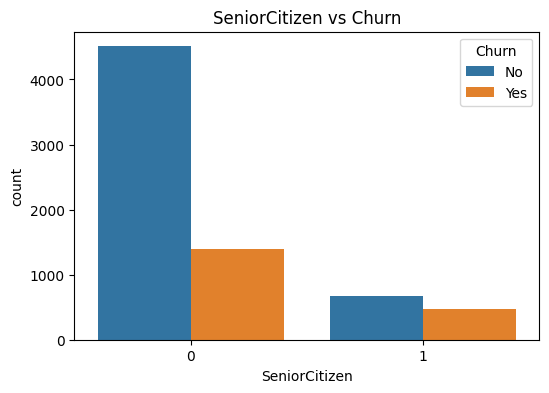

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=data)
plt.title('SeniorCitizen vs Churn')
plt.show()

Senior Citizens are more likely to churn then non-senior citizens

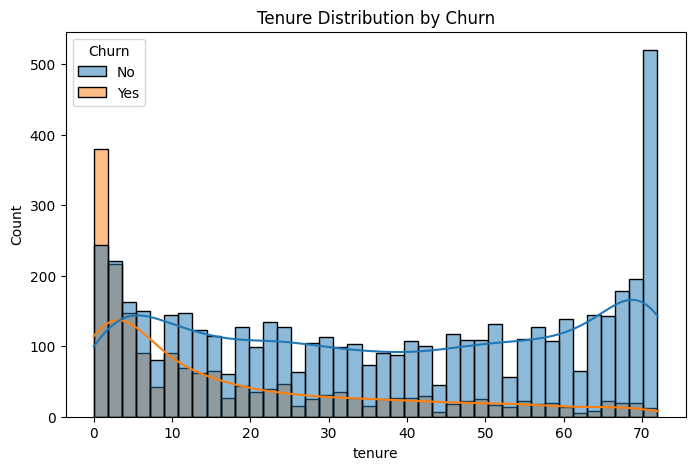

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(data=data, x='tenure', hue='Churn', bins=40, kde=True)
plt.title('Tenure Distribution by Churn')
plt.show()

New Customers are more likely to churn then old customers

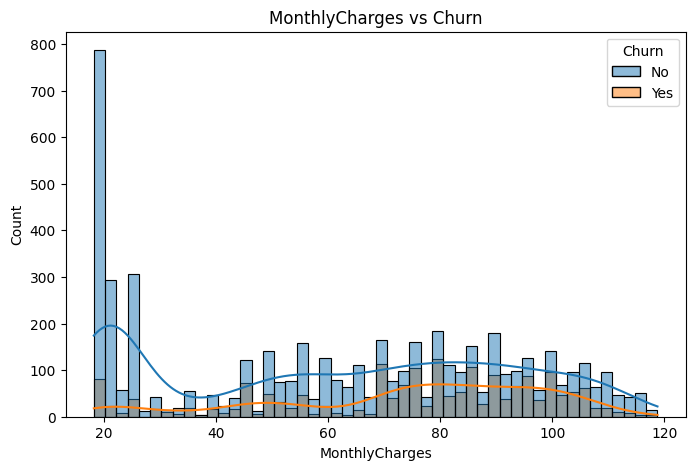

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(data=data, x='MonthlyCharges', hue='Churn', bins=50, kde=True)
plt.title('MonthlyCharges vs Churn')
plt.show()

Customers with less monthly charges are less likely to churn while customers with medium to high monthly charges are more likely to churn

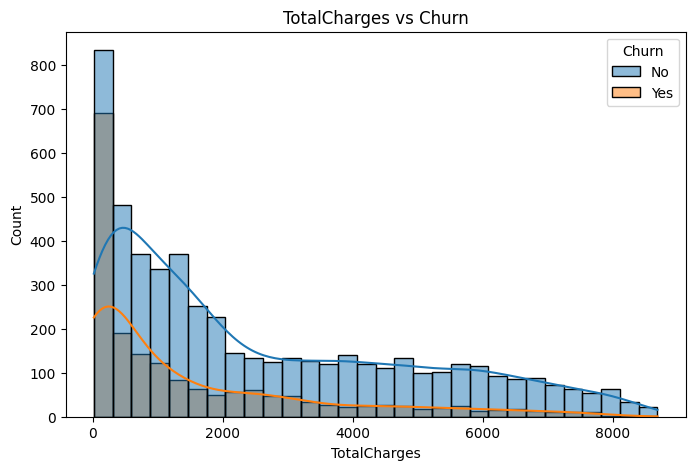

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(data=data, x='TotalCharges', hue='Churn', bins=30, kde=True)
plt.title('TotalCharges vs Churn')
plt.show()

This tells that new customers with less total charges are more likely to churn than those who have high total charges.

### Categorical Variables Analysis

In [25]:
for col in cat_cols:
  fig = px.histogram(data, x="Churn", color=col, barmode="group", title=f"<b>Churn VS {col} distribution<b>")
  fig.update_layout(width=700, height=500, bargap=0.1)
  fig.show()

 Gender Vs Churn: Gender don't have any significant effect on Churn.

 Partner Vs Churn: Customer without partners are more likely to Churn then those who have partners.

 Dependents Vs Churn: Customer with dependents are less likely to churn as compared to those who are without dependents.

 Phone Service Vs Churn: Most Customer avails the phone service so this feature is not differentiating the churned and Non-Churned customers.

 Multiple lines Vs Churn: Customers with Multiple lines are slightly more likely to Churn.

 Internet Service Vs Churn:
  - Customers with FiberOptic are most likely to Churn.
  - DSL users are less likely to churn.
  - Customers with no Internet Service are very minimal to Churn.

 Corelated Features:
- Online Backup, Online Security, Device Protection, Tech Support are co-related features. Customers without these services are more likely to Churn.
- Streaming TV & Streaming Movies are also co-related features. Both Features are not able to differentiate between churned and non-churned ones.

 Contract Vs Churn:
- Customers with Month to Month Contract are most likely to Churn.
- Customers with One Year contract are minimal to Churn.
- Only a very few Customers with two years contract Churned.
- Churn Vs Paper Less Billing Paper less billing Customers are more likely to churn as compare to those who haven't.

 Churn Vs Payment Method: Payment Methods effect the Churn rate of customers.

- Electronic Check Users are more likely to churn.
- The other 3 methods are very less likely to churn as compared to Electronic check.
- Mailed Check has low churn rate, Bank Transfer has more low churn rate even lower than mailed check, Credit Card User are mostly the non-churned customers.

In [28]:
data.to_csv('../Data/cleanedData.csv', index=False)